# Exercise 1: Classification with US Airline Sentiment Tweets

## Objective
Build a multi-layer feed-forward neural network (ANN) using PyTorch to classify tweets into three sentiment classes: Negative, Neutral, and Positive.

## Approach
- Compare two vectorization methods: **TF-IDF** and **Word2Vec**
- Include airline name as an additional feature
- Implement early stopping to prevent overfitting
- Evaluate using Accuracy, Precision, Recall, F1-score, and Confusion Matrix

## 1. Imports and Setup

In [7]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Zip Slip blocked: stopwords/


## 2. Data Loading and Exploratory Data Analysis (EDA)

In [8]:
df = pd.read_csv('Tweets.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (14640, 15)

Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [9]:
# Keep only relevant columns
df = df[['text', 'airline', 'airline_sentiment']]
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nSentiment distribution:")
print(df['airline_sentiment'].value_counts())

Missing values:
text                 0
airline              0
airline_sentiment    0
dtype: int64

Sentiment distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


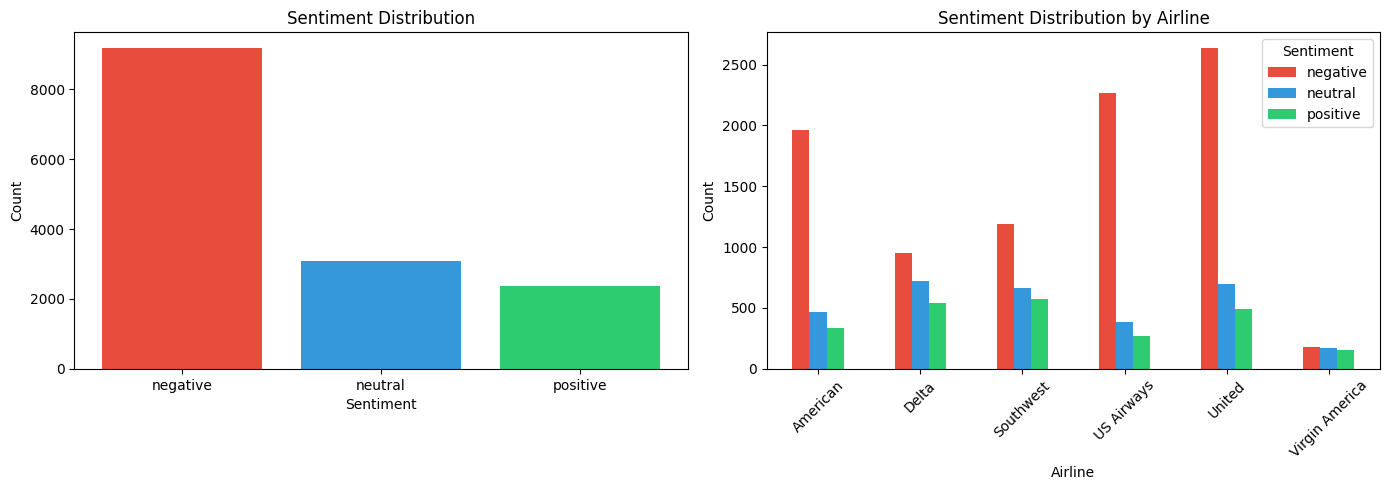


Class imbalance ratio (negative/positive): 3.88


In [10]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution
sentiment_counts = df['airline_sentiment'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Sentiment by airline
sentiment_airline = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
sentiment_airline.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Sentiment Distribution by Airline')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Count')
axes[1].legend(title='Sentiment')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio (negative/positive): {sentiment_counts['negative']/sentiment_counts['positive']:.2f}")

## 3. Text Preprocessing

We clean the tweets by:
- Removing mentions (@user), hashtags, URLs
- Converting to lowercase
- Removing punctuation and digits
- Removing stopwords
- Tokenizing the text

In [11]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean and preprocess tweet text."""
    text = text.lower()
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and digits
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

def tokenize_and_remove_stopwords(text):
    """Tokenize and remove stopwords."""
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Apply preprocessing
df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['clean_text'].apply(tokenize_and_remove_stopwords)

print("Sample cleaned tweets:")
for i in range(3):
    print(f"Original: {df['text'].iloc[i][:80]}...")
    print(f"Cleaned:  {df['clean_text'].iloc[i][:80]}")
    print(f"Tokens:   {df['tokens'].iloc[i][:10]}")
    print()

Sample cleaned tweets:
Original: @VirginAmerica What @dhepburn said....
Cleaned:  what said
Tokens:   ['said']

Original: @VirginAmerica plus you've added commercials to the experience... tacky....
Cleaned:  plus youve added commercials to the experience tacky
Tokens:   ['plus', 'youve', 'added', 'commercials', 'experience', 'tacky']

Original: @VirginAmerica I didn't today... Must mean I need to take another trip!...
Cleaned:  i didnt today must mean i need to take another trip
Tokens:   ['didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']



## 4. Prepare Labels and Train/Test Split

In [12]:
# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])
print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

# Encode airline names (one-hot encoding will be used later)
airline_encoder = LabelEncoder()
df['airline_encoded'] = airline_encoder.fit_transform(df['airline'])
n_airlines = len(airline_encoder.classes_)
print(f"Airlines: {airline_encoder.classes_}")

# Split data
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, df['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)

# Calculate class weights for imbalanced data
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)
print(f"\nTrain size: {len(X_train_df)}, Test size: {len(X_test_df)}")
print(f"Class weights: {class_weights}")

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Airlines: ['American' 'Delta' 'Southwest' 'US Airways' 'United' 'Virgin America']

Train size: 11712, Test size: 2928
Class weights: tensor([0.3823, 1.1324, 1.4853], device='cuda:0')


## 5. Feature Extraction

We compare two vectorization methods:
1. **TF-IDF**: Term Frequency-Inverse Document Frequency - captures word importance based on frequency
2. **Word2Vec**: Learns dense word embeddings that capture semantic meaning

Both methods will include airline information as additional features.

### 5.1 TF-IDF Vectorization

In [13]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_df['clean_text']).toarray()
X_test_tfidf = tfidf.transform(X_test_df['clean_text']).toarray()

# Add one-hot encoded airline features
def get_airline_onehot(df_subset, n_airlines):
    """Create one-hot encoding for airlines."""
    onehot = np.zeros((len(df_subset), n_airlines))
    for i, idx in enumerate(df_subset.index):
        onehot[i, df_subset.loc[idx, 'airline_encoded']] = 1
    return onehot

train_airline_onehot = get_airline_onehot(X_train_df, n_airlines)
test_airline_onehot = get_airline_onehot(X_test_df, n_airlines)

# Combine TF-IDF features with airline features
X_train_tfidf_combined = np.hstack([X_train_tfidf, train_airline_onehot])
X_test_tfidf_combined = np.hstack([X_test_tfidf, test_airline_onehot])

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Combined feature shape (TF-IDF + airline): {X_train_tfidf_combined.shape}")

TF-IDF feature shape: (11712, 5000)
Combined feature shape (TF-IDF + airline): (11712, 5006)


### 5.2 Word2Vec Vectorization

In [14]:
# Train Word2Vec on training data
EMBEDDING_DIM = 100
w2v_model = Word2Vec(
    sentences=X_train_df['tokens'].tolist(),
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_STATE
)

def get_sentence_embedding(tokens, model, dim):
    """Average word vectors to get sentence embedding."""
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

# Create embeddings for train and test
X_train_w2v = np.array([get_sentence_embedding(tokens, w2v_model, EMBEDDING_DIM) 
                         for tokens in X_train_df['tokens']])
X_test_w2v = np.array([get_sentence_embedding(tokens, w2v_model, EMBEDDING_DIM) 
                        for tokens in X_test_df['tokens']])

# Combine with airline features
X_train_w2v_combined = np.hstack([X_train_w2v, train_airline_onehot])
X_test_w2v_combined = np.hstack([X_test_w2v, test_airline_onehot])

print(f"Word2Vec embedding shape: {X_train_w2v.shape}")
print(f"Combined feature shape (Word2Vec + airline): {X_train_w2v_combined.shape}")

Word2Vec embedding shape: (11712, 100)
Combined feature shape (Word2Vec + airline): (11712, 106)


## 6. Build the ANN Classifier

The neural network architecture:
- Input layer (size depends on vectorization method)
- Hidden layer 1: 256 neurons with ReLU + BatchNorm + Dropout
- Hidden layer 2: 128 neurons with ReLU + BatchNorm + Dropout
- Output layer: 3 neurons (one per class)

In [15]:
class SentimentClassifier(nn.Module):
    def __init__(self, input_size, hidden1=256, hidden2=128, num_classes=3, dropout=0.3):
        super(SentimentClassifier, self).__init__()
        
        self.layer1 = nn.Linear(input_size, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.dropout1 = nn.Dropout(dropout)
        
        self.layer2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.dropout2 = nn.Dropout(dropout)
        
        self.output = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout2(x)
        x = self.output(x)
        return x

In [16]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=5):
    """Train the model with early stopping."""
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=patience)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    return train_losses, val_losses

In [17]:
def evaluate_model(model, test_loader, label_encoder):
    """Evaluate model and return predictions and metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted'),
        'recall': recall_score(all_labels, all_preds, average='weighted'),
        'f1': f1_score(all_labels, all_preds, average='weighted')
    }
    
    return all_preds, all_labels, metrics


def prepare_data_loaders(X_train, X_test, y_train, y_test, batch_size=64):
    """Create PyTorch DataLoaders."""
    # Split training data for validation
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
    )
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train_split)
    y_train_t = torch.LongTensor(y_train_split.values if hasattr(y_train_split, 'values') else y_train_split)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size)
    
    return train_loader, val_loader, test_loader

## 7. Train and Evaluate Models

### 7.1 TF-IDF Model

In [18]:
# Prepare data loaders for TF-IDF
train_loader_tfidf, val_loader_tfidf, test_loader_tfidf = prepare_data_loaders(
    X_train_tfidf_combined, X_test_tfidf_combined, y_train, y_test
)

# Create and train TF-IDF model
input_size_tfidf = X_train_tfidf_combined.shape[1]
model_tfidf = SentimentClassifier(input_size_tfidf).to(device)

print("Training TF-IDF Model...")
print("-" * 50)
train_losses_tfidf, val_losses_tfidf = train_model(
    model_tfidf, train_loader_tfidf, val_loader_tfidf, epochs=50, patience=7
)

Training TF-IDF Model...
--------------------------------------------------
Early stopping at epoch 8


### 7.2 Word2Vec Model

In [19]:
# Prepare data loaders for Word2Vec
train_loader_w2v, val_loader_w2v, test_loader_w2v = prepare_data_loaders(
    X_train_w2v_combined, X_test_w2v_combined, y_train, y_test
)

# Create and train Word2Vec model
input_size_w2v = X_train_w2v_combined.shape[1]
model_w2v = SentimentClassifier(input_size_w2v).to(device)

print("Training Word2Vec Model...")
print("-" * 50)
train_losses_w2v, val_losses_w2v = train_model(
    model_w2v, train_loader_w2v, val_loader_w2v, epochs=50, patience=7
)

Training Word2Vec Model...
--------------------------------------------------
Epoch 10/50 - Train Loss: 0.8771, Val Loss: 1.0451
Epoch 20/50 - Train Loss: 0.8504, Val Loss: 0.9110
Early stopping at epoch 26


## 8. Model Evaluation and Comparison

In [20]:
# Evaluate both models
preds_tfidf, labels_tfidf, metrics_tfidf = evaluate_model(model_tfidf, test_loader_tfidf, label_encoder)
preds_w2v, labels_w2v, metrics_w2v = evaluate_model(model_w2v, test_loader_w2v, label_encoder)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'TF-IDF': [metrics_tfidf['accuracy'], metrics_tfidf['precision'], 
               metrics_tfidf['recall'], metrics_tfidf['f1']],
    'Word2Vec': [metrics_w2v['accuracy'], metrics_w2v['precision'], 
                 metrics_w2v['recall'], metrics_w2v['f1']]
})

print("Model Comparison:")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 50)

best_model = 'TF-IDF' if metrics_tfidf['f1'] > metrics_w2v['f1'] else 'Word2Vec'
print(f"\nBest performing model based on F1-Score: {best_model}")

Model Comparison:
   Metric   TF-IDF  Word2Vec
 Accuracy 0.740096  0.410861
Precision 0.755902  0.696848
   Recall 0.740096  0.410861
 F1-Score 0.746117  0.431438


Best performing model based on F1-Score: TF-IDF


In [21]:
# Detailed classification reports
print("TF-IDF Model - Classification Report:")
print("-" * 50)
print(classification_report(labels_tfidf, preds_tfidf, target_names=label_encoder.classes_))

print("\nWord2Vec Model - Classification Report:")
print("-" * 50)
print(classification_report(labels_w2v, preds_w2v, target_names=label_encoder.classes_))

TF-IDF Model - Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    negative       0.87      0.80      0.83      1835
     neutral       0.53      0.61      0.57       620
    positive       0.62      0.68      0.65       473

    accuracy                           0.74      2928
   macro avg       0.67      0.70      0.68      2928
weighted avg       0.76      0.74      0.75      2928


Word2Vec Model - Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    negative       0.91      0.31      0.46      1835
     neutral       0.42      0.40      0.40       620
    positive       0.23      0.84      0.36       473

    accuracy                           0.41      2928
   macro avg       0.52      0.51      0.41      2928
weighted avg       0.70      0.41      0.43      2928



## 9. Visualizations

### 9.1 Training Loss Curves

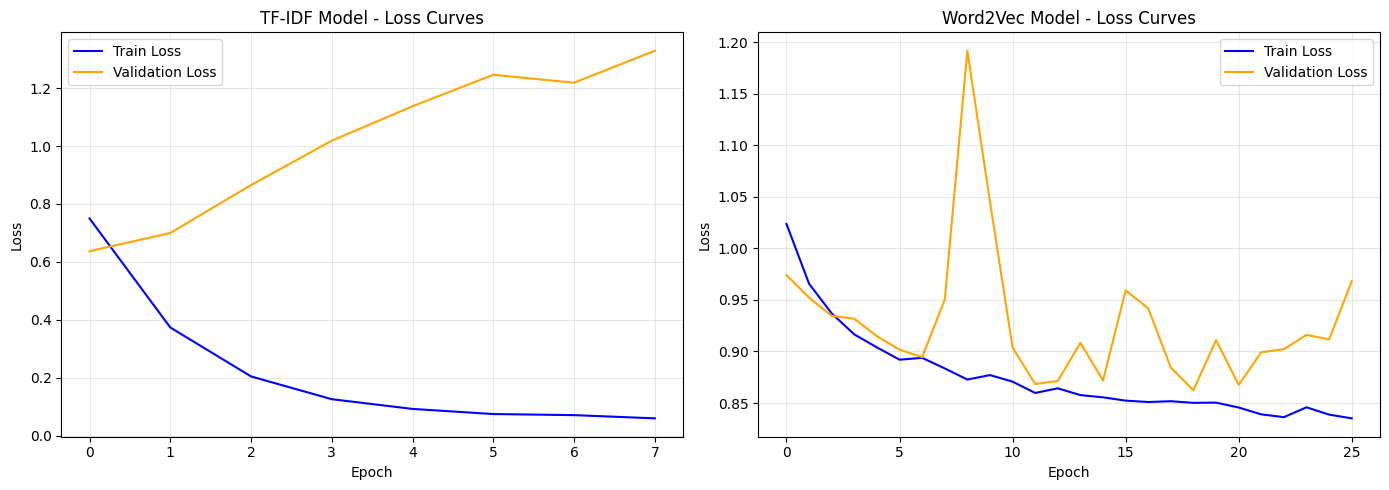

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF-IDF loss curves
axes[0].plot(train_losses_tfidf, label='Train Loss', color='blue')
axes[0].plot(val_losses_tfidf, label='Validation Loss', color='orange')
axes[0].set_title('TF-IDF Model - Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Word2Vec loss curves
axes[1].plot(train_losses_w2v, label='Train Loss', color='blue')
axes[1].plot(val_losses_w2v, label='Validation Loss', color='orange')
axes[1].set_title('Word2Vec Model - Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.2 Confusion Matrices

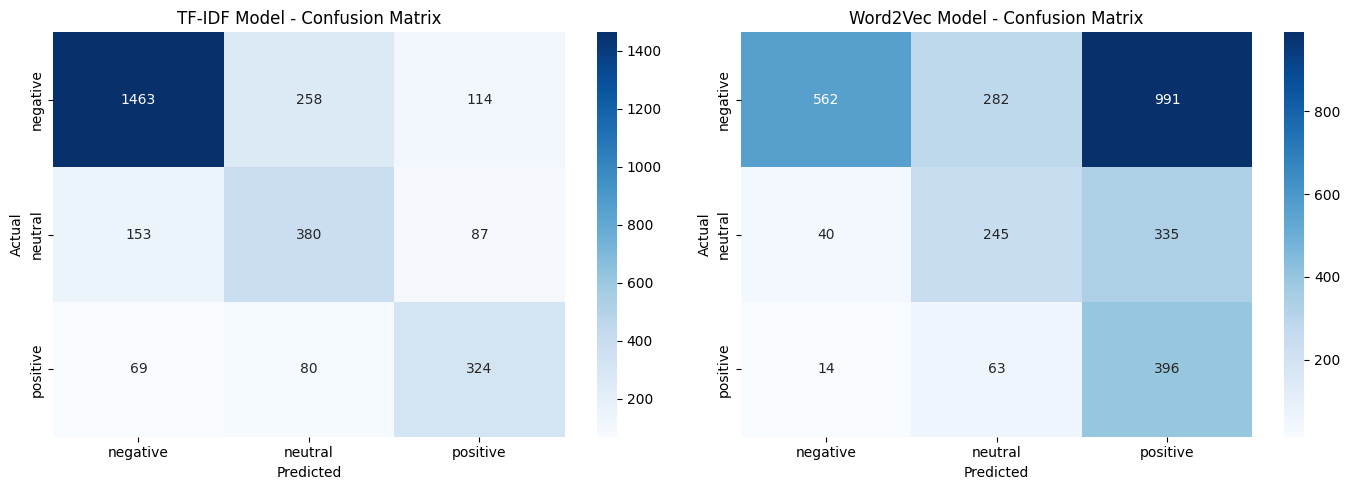

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF-IDF confusion matrix
cm_tfidf = confusion_matrix(labels_tfidf, preds_tfidf)
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title('TF-IDF Model - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Word2Vec confusion matrix
cm_w2v = confusion_matrix(labels_w2v, preds_w2v)
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title('Word2Vec Model - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 9.3 Performance Metrics Comparison

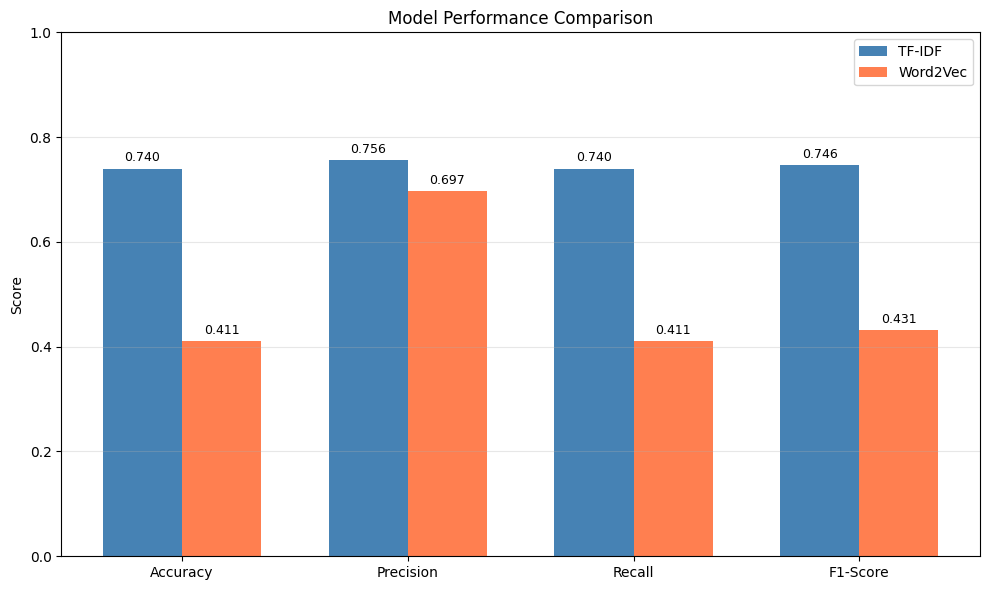

In [24]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
tfidf_scores = [metrics_tfidf['accuracy'], metrics_tfidf['precision'], 
                metrics_tfidf['recall'], metrics_tfidf['f1']]
w2v_scores = [metrics_w2v['accuracy'], metrics_w2v['precision'], 
              metrics_w2v['recall'], metrics_w2v['f1']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, tfidf_scores, width, label='TF-IDF', color='steelblue')
bars2 = ax.bar(x + width/2, w2v_scores, width, label='Word2Vec', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Conclusion

In this exercise, we built a feed-forward neural network (ANN) using PyTorch to classify US Airline tweets into three sentiment classes (Negative, Neutral, Positive). We compared two vectorization methods: **TF-IDF** and **Word2Vec**, both combined with one-hot encoded airline features.

### Results

| Metric     | TF-IDF | Word2Vec |
|------------|--------|----------|
| Accuracy   | 0.740  | 0.411    |
| Precision  | 0.756  | 0.697    |
| Recall     | 0.740  | 0.411    |
| F1-Score   | 0.746  | 0.431    |

**TF-IDF** clearly outperformed **Word2Vec** across all metrics. The TF-IDF model achieved a **74% accuracy** and an **F1-score of 0.746**, while Word2Vec only reached **41% accuracy** and an **F1-score of 0.431**.

### Key Observations

- **Class imbalance**: The dataset is heavily imbalanced — negative tweets dominate (~9,100 out of ~14,600). We handled this by using class weights in the loss function.
- **TF-IDF model** trained for only **8 epochs** before early stopping kicked in, meaning it converged quickly. Its confusion matrix shows it correctly classified most negative tweets (1463 out of 1835) and performed reasonably on neutral (380/620) and positive (324/473) classes.
- **Word2Vec model** trained for **26 epochs** but struggled significantly. Its confusion matrix reveals it misclassified 991 negative tweets as positive, which explains its low accuracy. The simple averaging of word embeddings likely loses too much information for this task.
- The **loss curves** confirm these findings: the TF-IDF model's training loss dropped sharply, while the Word2Vec model's losses remained high and unstable throughout training.

### Why TF-IDF Worked Better

TF-IDF captures word importance through term frequency and inverse document frequency, which is effective for sentiment classification where specific words (e.g., "delayed", "terrible", "great") are strong indicators. Word2Vec, while able to capture semantic relationships, loses information when averaging word vectors into a single sentence embedding — especially for short texts like tweets.

### Summary

The TF-IDF-based ANN is the better model for this sentiment classification task, achieving solid performance (F1 = 0.746) despite the class imbalance. The results show that for this type of text classification, simpler vectorization methods like TF-IDF can outperform dense embedding approaches when used with a straightforward feed-forward network.